<a href="https://colab.research.google.com/github/miqi4/PCVK_2026/blob/main/PcvkWeek5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Tulis nama lengkap Anda'
NIM  = '2141720000'          # ganti dengan NIM Anda

N     = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Tulis nama lengkap Anda
NIM    : 2141720000 | N = 0
bins   : 8
clip   : 1.0
tile   : 2
L      : 2
WAKTU  : 2026-09-28 10:29:25 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 09d231af5ff82b84


# Week5 - Histogram, Histogram Equalization, dan Dithering
Notebook ini mengikuti Modul 5. **Cara pakai:** (1) ganti `NAMA` dan `NIM` di sel pertama, (2) taruh gambar di Google Drive (`MyDrive/PCVK/Images`), atau upload zip `bahan_praktikum.zip` ke `/content` lalu unzip, (3) jalankan sel dari atas ke bawah.
Tahap 1 = pakai citra contoh (`lena.jpg`, `lena_lc.jpg`). Tahap 2 = pakai citra KTM Anda sendiri.

In [2]:
# --- Siapkan Drive, library, dan folder gambar ---
import os, math, glob
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Drive tidak dipasang (tidak apa-apa bila memakai upload):', e)

CONTOH = '/content/drive/MyDrive/PCVK/Images'          # citra contoh bersama
BASE   = '/content/drive/MyDrive/PCVK/Images/' + NIM   # citra KTM milik Anda

# Cadangan: bila folder Drive belum ada, pakai folder hasil unzip bahan_praktikum.zip
if not os.path.exists(CONTOH + '/lena.jpg'):
    CONTOH = '/content/bahan'
if not os.path.exists(BASE + '/KTM1b.jpg'):
    BASE = '/content/bahan'
print('CONTOH =', CONTOH); print('BASE   =', BASE)

def jud(t):                      # judul wajib memuat NIM
    return NIM + ' - ' + t
def baca(path, gray=False):
    img = cv.imread(path, cv.IMREAD_GRAYSCALE if gray else cv.IMREAD_COLOR)
    assert img is not None, 'Gambar tidak ditemukan: ' + path
    return img

# Area yang dipakai untuk menilai keterbacaan/noise (x1, y1, x2, y2).
# Untuk KTM asli Anda, ubah kotak ini agar pas dengan area NIM/nama dan area polos kartu.
ROI_TEKS  = (290, 150, 850, 410)
ROI_POLOS = (20, 435, 280, 520)
def potong(img, roi):
    x1, y1, x2, y2 = roi
    return img[y1:y2, x1:x2]

Mounted at /content/drive
CONTOH = /content/drive/MyDrive/PCVK/Images
BASE   = /content/bahan


# E-1 Percobaan Histogram

## E-1 langkah 3: histogram manual (Tahap 1: lena.jpg, Tahap 2: KTM1b.jpg)

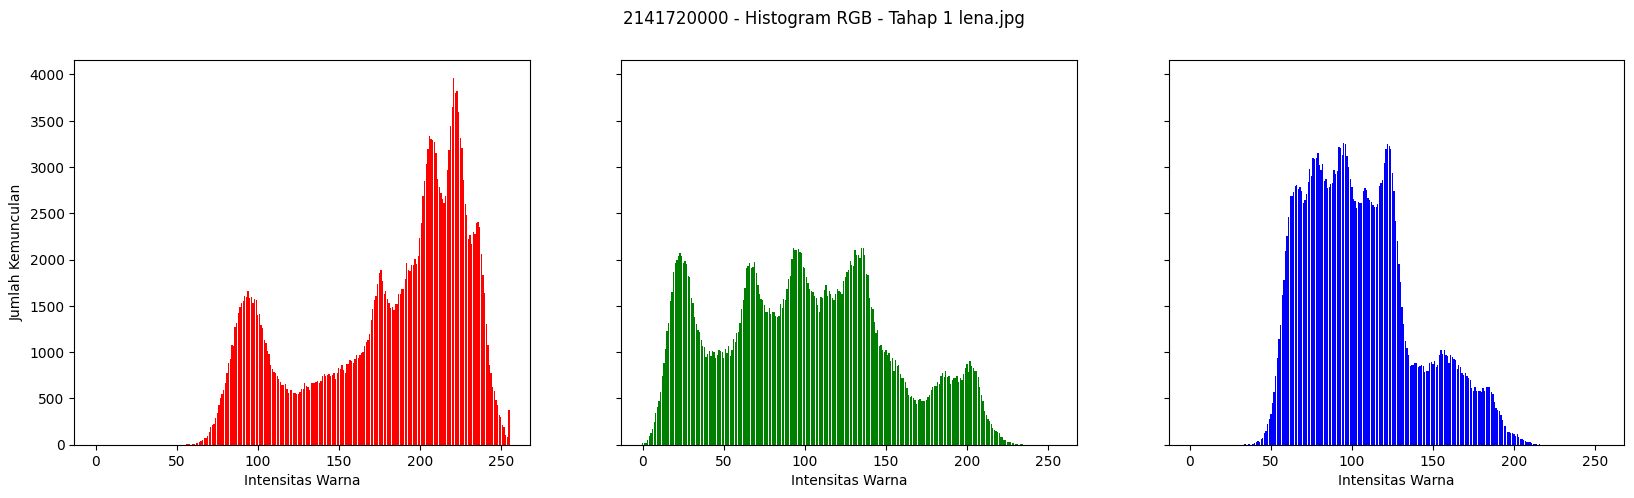

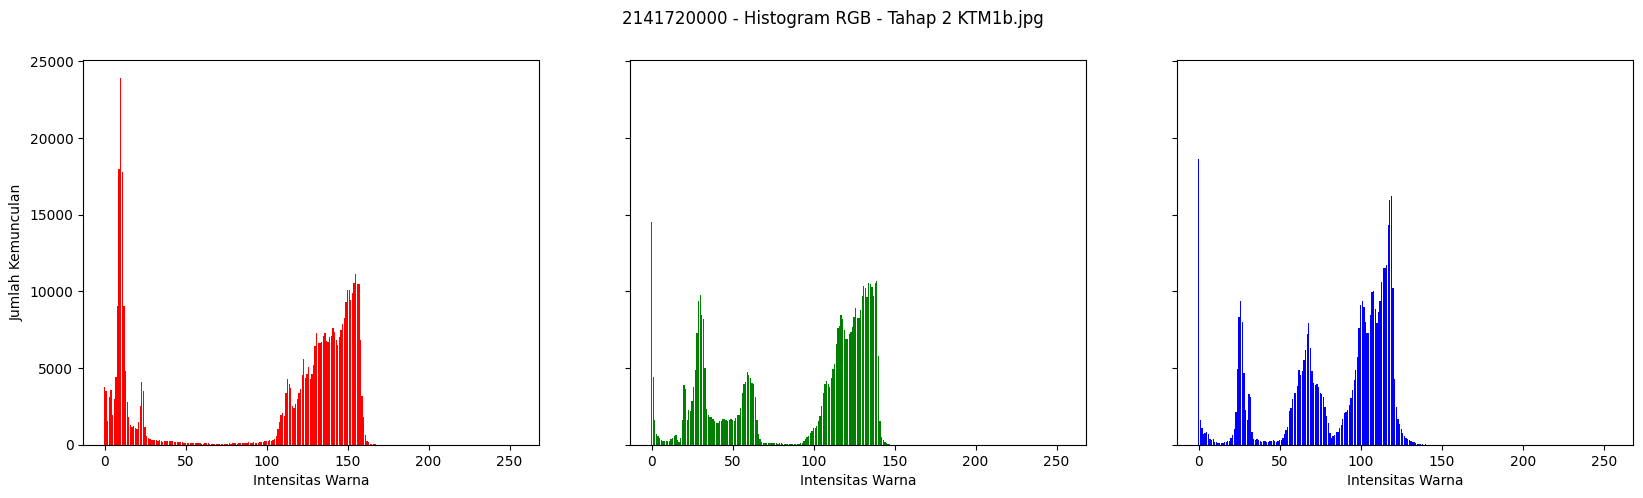

In [3]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)          # 1. siapkan penghitung, isi 0
    for y in range(img.shape[0]):            # 2. telusuri setiap baris
        for x in range(img.shape[1]):        #    dan setiap kolom
            h[img[y, x]] += 1                # 3. tambah 1 sesuai nilai piksel
    return h

def plot_rgb_manual(path, judul):
    bgr = baca(path)
    rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
    fig.suptitle(jud('Histogram RGB - ' + judul))
    for ax, i, warna in zip(axs, range(3), ['red', 'green', 'blue']):
        h = histogram_manual(rgb[:, :, i])
        assert h.sum() == rgb.shape[0] * rgb.shape[1]
        ax.bar(np.arange(256), h, color=warna)
        ax.set_xlabel('Intensitas Warna')
    axs[0].set_ylabel('Jumlah Kemunculan')
    plt.show()

plot_rgb_manual(CONTOH + '/lena.jpg', 'Tahap 1 lena.jpg')
plot_rgb_manual(BASE + '/KTM1b.jpg',  'Tahap 2 KTM1b.jpg')

## Pertanyaan E-1 no. 1: histogram manual vs `np.histogram` vs `cv.calcHist`

In [4]:
def bandingkan_tiga(path, judul):
    g = baca(path, gray=True)
    h_man = histogram_manual(g)
    h_np  = np.histogram(g, bins=256, range=(0, 256))[0]
    h_cv  = cv.calcHist([g], [0], None, [256], [0, 256]).flatten().astype(np.int64)
    d1 = np.abs(h_man - h_np).max(); d2 = np.abs(h_man - h_cv).max(); d3 = np.abs(h_np - h_cv).max()
    print('%-14s | manual-numpy: %d | manual-calcHist: %d | numpy-calcHist: %d' % (judul, d1, d2, d3))
    assert d1 == 0 and d2 == 0 and d3 == 0
bandingkan_tiga(CONTOH + '/lena.jpg', 'lena.jpg')
bandingkan_tiga(BASE + '/KTM1b.jpg',  'KTM1b.jpg')
print(jud('Selisih maksimum = 0 -> ketiga cara menghasilkan histogram yang persis sama'))

lena.jpg       | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0
KTM1b.jpg      | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0
2141720000 - Selisih maksimum = 0 -> ketiga cara menghasilkan histogram yang persis sama


## Pertanyaan E-1 no. 2: histogram ternormalisasi p(j) dan CDF untuk KTM1a-KTM1d (figure 2 x 2)

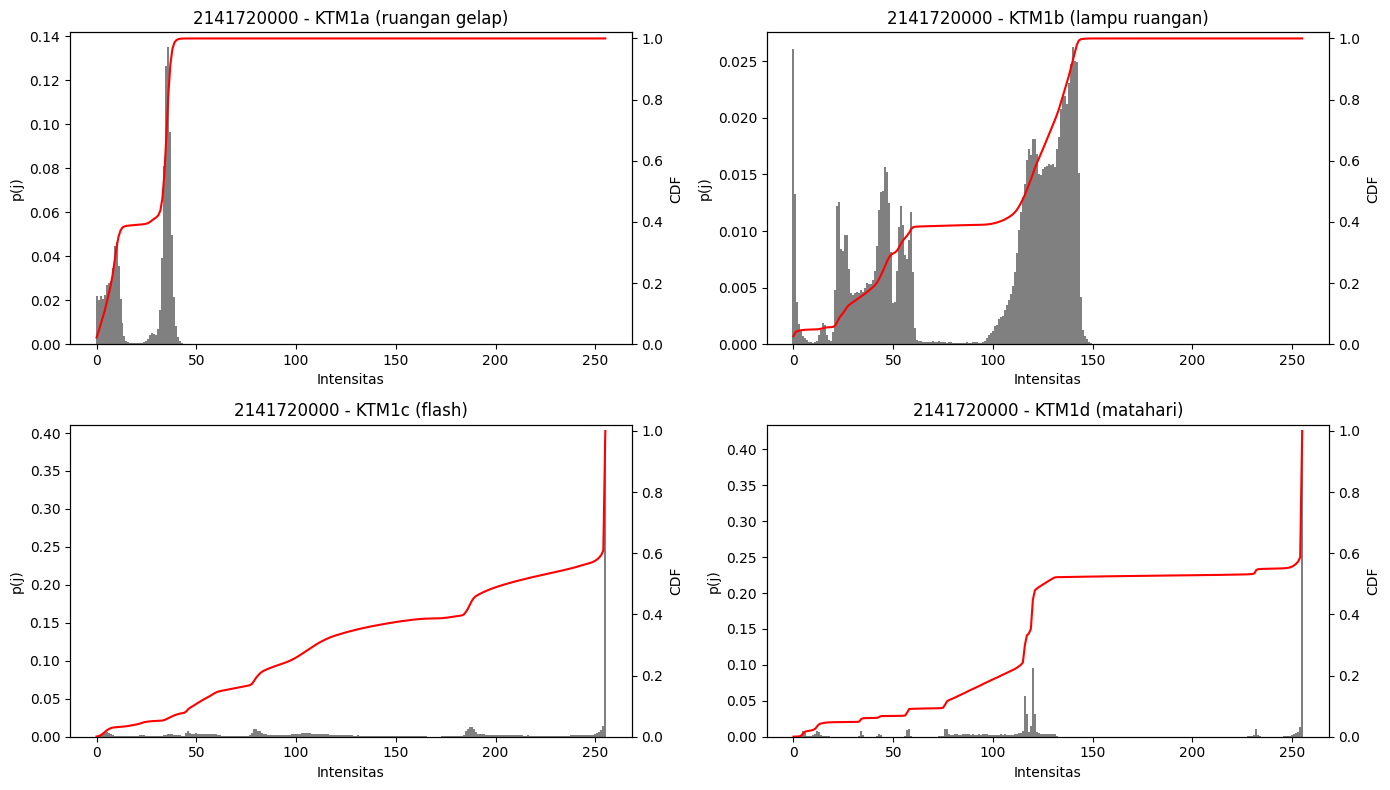

Citra   Kondisi          Rerata   Median   % piksel<=63  % piksel>=192
KTM1a   ruangan gelap      24.3       34         100.0%           0.0%
KTM1b   lampu ruangan      92.3      117          38.5%           0.0%
KTM1c   flash             177.1      206          15.1%          53.7%
KTM1d   matahari          171.0      126           9.2%          47.3%


In [5]:
nama_file = ['KTM1a', 'KTM1b', 'KTM1c', 'KTM1d']
ket = {'KTM1a': 'ruangan gelap', 'KTM1b': 'lampu ruangan', 'KTM1c': 'flash', 'KTM1d': 'matahari'}
ringkas = {}
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
for ax, n in zip(axs.ravel(), nama_file):
    g = baca(BASE + '/' + n + '.jpg', gray=True)
    p = np.bincount(g.ravel(), minlength=256) / g.size
    cdf = np.cumsum(p)
    ax.bar(np.arange(256), p, color='gray', width=1.0, label='p(j)')
    ax.set_ylabel('p(j)'); ax.set_xlabel('Intensitas')
    ax2 = ax.twinx(); ax2.plot(cdf, color='red', label='CDF'); ax2.set_ylim(0, 1.02); ax2.set_ylabel('CDF')
    ax.set_title(jud(n + ' (' + ket[n] + ')'))
    ringkas[n] = dict(rerata=g.mean(), median=int(np.searchsorted(cdf, 0.5)),
                      gelap=cdf[63], terang=max(0.0, 1 - cdf[191]))
plt.tight_layout(); plt.show()
print('%-7s %-14s %8s %8s %14s %14s' % ('Citra', 'Kondisi', 'Rerata', 'Median', '% piksel<=63', '% piksel>=192'))
for n in nama_file:
    r = ringkas[n]
    print('%-7s %-14s %8.1f %8d %13.1f%% %13.1f%%' % (n, ket[n], r['rerata'], r['median'], r['gelap']*100, r['terang']*100))

**Jawaban (isi dengan kata-kata sendiri, berdasarkan angka di atas dan gambar milik Anda):**
Pada citra paling gelap, kurva CDF naik sangat cepat di sisi kiri (intensitas rendah) lalu mendatar, karena hampir semua piksel bernilai kecil. Pada citra paling terang, kurva CDF baru naik tajam di sisi kanan, dan bagian kirinya hampir datar. Bentuk ini cocok dengan kondisi saat foto diambil: ruangan gelap membuat cahaya yang masuk ke kamera sedikit, sedangkan cahaya matahari atau flash membuat banyak piksel terang (bahkan jenuh di 255). Tulis kondisi nyata saat Anda memotret pada Pertemuan 2.

## Pertanyaan E-1 no. 3: jumlah bin PARAM['bins'] vs 256 bin

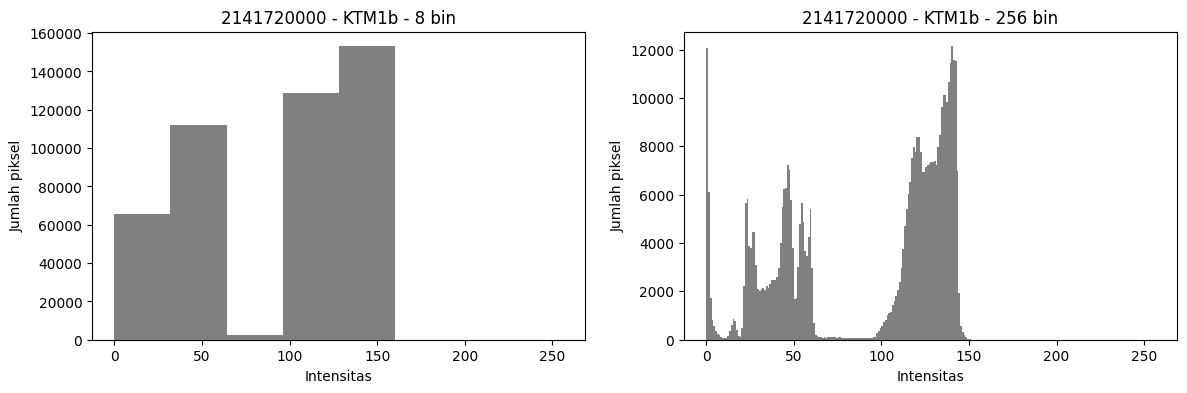

In [6]:
g = baca(BASE + '/KTM1b.jpg', gray=True)
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
for ax, b in zip(axs, [PARAM['bins'], 256]):
    ax.hist(g.ravel(), bins=b, range=(0, 256), color='gray')
    ax.set_title(jud('KTM1b - %d bin' % b)); ax.set_xlabel('Intensitas'); ax.set_ylabel('Jumlah piksel')
plt.show()

**Jawaban:** Bila jumlah bin dikurangi, beberapa nilai intensitas yang berdekatan digabung menjadi satu batang. Akibatnya detail halus hilang: puncak-puncak kecil, lembah sempit, dan celah antar-nilai (misalnya piksel jenuh di 255 atau nilai yang sama sekali tidak muncul) tidak lagi terlihat. Yang tersisa hanya bentuk umum sebaran. Kelebihannya grafik lebih mudah dibaca dan tidak terlalu "berduri".

# E-2 Percobaan Histogram Equalization

## E-2 langkah 1: equalization manual (Tahap 1: lena_lc.jpg, Tahap 2: KTM1a.jpg)

In [ ]:
def he_manual_lut(g):
    """Sesuai modul: K = round(C_i * (2^k - 1) / (w*h)), lalu dipetakan ke semua piksel."""
    h   = histogram_manual(g)                  # frekuensi
    cdf = np.cumsum(h)                         # jumlah kumulatif
    K   = np.round(cdf * 255 / g.size).astype(np.uint8)   # skala warna
    return K
def he_manual(g):
    return he_manual_lut(g)[g]                 # transformasi kembali menjadi citra

def he_manual_color(bgr):
    return cv.merge([he_manual(c) for c in cv.split(bgr)])

# --- Tahap 1: lena_lc (berwarna, tiap kanal) ---
lc = baca(CONTOH + '/lena_lc.jpg'); lc_he = he_manual_color(lc)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(lc, cv.COLOR_BGR2RGB)); plt.title(jud('lena_lc asli')); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(lc_he, cv.COLOR_BGR2RGB)); plt.title(jud('lena_lc hasil HE manual')); plt.axis('off')
plt.show()

fig, axs = plt.subplots(2, 3, figsize=(20, 7), sharex=True)
fig.suptitle(jud('Histogram RGB lena_lc: atas = sebelum, bawah = sesudah HE'))
for j, warna in enumerate(['blue', 'green', 'red']):
    axs[0, 2-j].bar(np.arange(256), histogram_manual(lc[:, :, j]), color=warna)
    axs[1, 2-j].bar(np.arange(256), histogram_manual(lc_he[:, :, j]), color=warna)
plt.show()

# --- Tahap 2: KTM1a (grayscale dan berwarna) ---
ktm_a = baca(BASE + '/KTM1a.jpg'); ktm_a_he = he_manual_color(ktm_a)
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(ktm_a, cv.COLOR_BGR2RGB)); plt.title(jud('KTM1a asli')); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(ktm_a_he, cv.COLOR_BGR2RGB)); plt.title(jud('KTM1a hasil HE manual')); plt.axis('off')
plt.show()

## E-2 langkah 2: `cv.equalizeHist` vs manual (selisih maksimum)

In [ ]:
def selisih_maks(path, judul):
    g   = baca(path, gray=True)
    man = he_manual(g)
    ocv = cv.equalizeHist(g)
    d = np.abs(man.astype(int) - ocv.astype(int))
    print('%-12s selisih maksimum = %d | piksel berbeda = %.2f%%' % (judul, d.max(), (d > 0).mean() * 100))
    return g

selisih_maks(CONTOH + '/lena_lc.jpg', 'lena_lc.jpg')
g_a = selisih_maks(BASE + '/KTM1a.jpg', 'KTM1a.jpg')

# Pembuktian penyebab: OpenCV memakai CDF yang dikurangi nilai CDF minimum (cdf_min)
def he_manual_cdfmin(g):
    h = histogram_manual(g); cdf = np.cumsum(h); cmin = cdf[cdf > 0].min()
    lut = np.round((cdf - cmin) / (g.size - cmin) * 255).clip(0, 255).astype(np.uint8)
    return lut[g]
for path in [CONTOH + '/lena_lc.jpg', BASE + '/KTM1a.jpg']:
    g = baca(path, gray=True)
    print(os.path.basename(path), '-> selisih HE manual (versi cdf_min) vs equalizeHist:',
          np.abs(he_manual_cdfmin(g).astype(int) - cv.equalizeHist(g).astype(int)).max())

**Jawaban:** Selisihnya tidak nol karena rumus di modul ($K=\text{round}(C_i\cdot 255/(w\cdot h))$) sedikit berbeda dengan yang dipakai OpenCV. OpenCV mengurangi nilai CDF terkecil (`cdf_min`) terlebih dahulu supaya intensitas terendah yang ada di citra dipetakan tepat ke 0. Sel di atas membuktikannya: bila rumus manual diberi `cdf_min`, selisihnya menjadi 0.

## E-2 langkah 3: ekualisasi berwarna cara 1 (tiap kanal B, G, R)

In [ ]:
bgr_lena = baca(CONTOH + '/lena.jpg')
bgr_ktm  = baca(BASE + '/KTM1d.jpg')

def cara1(bgr):
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    return cv.merge(kanal)

plt.figure(figsize=(14, 8))
for k, (b, t) in enumerate([(bgr_lena, 'lena.jpg'), (bgr_ktm, 'KTM1d.jpg')]):
    plt.subplot(2, 2, 2*k+1); plt.imshow(cv.cvtColor(b, cv.COLOR_BGR2RGB)); plt.title(jud(t + ' asli')); plt.axis('off')
    plt.subplot(2, 2, 2*k+2); plt.imshow(cv.cvtColor(cara1(b), cv.COLOR_BGR2RGB)); plt.title(jud(t + ' - HE per kanal B,G,R')); plt.axis('off')
plt.show()

## E-2 langkah 4: ekualisasi hanya kanal terang (Y / V / L) + tabel pergeseran Hue

In [ ]:
def semua_cara(bgr):
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb); y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV); h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB); l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)
    return [bgr, cara1(bgr), he_y, he_v, he_l]

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d  = np.abs(h1 - h2)
    d  = np.minimum(d, 180 - d)          # Hue melingkar 0-179
    return d.mean()

def tampil_dan_tabel(bgr, nama):
    citra = semua_cara(bgr)
    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i); plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(jud(nama + ' - ' + t), fontsize=8); plt.axis('off')
    plt.show()
    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    hasil = {}
    for t, c in zip(judul, citra):
        gs = geser_hue(bgr, c) * 2; tr = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
        hasil[t] = (gs, tr)
        print('%-22s %16.2f %16.1f' % (t, gs, tr))
    return hasil

print('=== Tahap 1: lena.jpg ==='); tab_lena = tampil_dan_tabel(bgr_lena, 'lena')
print('=== Tahap 2: KTM1d.jpg ==='); tab_ktm  = tampil_dan_tabel(bgr_ktm, 'KTM1d')

In [ ]:
# Jawaban otomatis pertanyaan no. 1 (dari angka di tabel KTM1d)
uji = {k: v[0] for k, v in tab_ktm.items() if k != 'Asli'}
terbesar = max(uji, key=uji.get)
print('Pergeseran Hue terbesar: "%s" = %.2f derajat' % (terbesar, uji[terbesar]))

**Jawaban pertanyaan no. 1-3 (lengkapi dengan angka tabel Anda):**
No. 1: cara yang paling menggeser Hue biasanya *ekualisasi tiap kanal B, G, R*, karena rasio antar kanal berubah sehingga jenis warna ikut berubah. Tulis nilainya dari sel di atas.
No. 2: pada cara kanal terang, Hue tidak persis nol karena setelah kanal terang diubah, citra dikembalikan ke BGR dengan **pembulatan** ke bilangan bulat dan **pemotongan** (clipping) ke rentang 0-255. Galat kecil ini muncul kembali saat citra diubah ke HSV, sehingga Hue bergeser sedikit, terutama pada piksel yang sangat gelap/terang atau hampir abu-abu (saturasi kecil).
No. 3: pilih salah satu kanal (Y, V, atau L) berdasarkan angka pergeseran Hue terkecil dan tampilan bagian kartu yang penting (misalnya area foto berwarna merah/biru dan tulisan NIM). Sebutkan alasan dan bagian citranya.

In [ ]:
# No. 4: CLAHE pada kanal terang (Y) memakai parameter dari NIM
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
def he_y_clahe(bgr):
    y, cr, cb = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb))
    return cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)

y_biasa = semua_cara(bgr_ktm)[2]
y_clahe = he_y_clahe(bgr_ktm)
print('%-26s %16s %16s' % ('Cara (KTM1d)', 'geser Hue (der)', 'rerata terang'))
for t, c in [('Asli', bgr_ktm), ('equalizeHist kanal Y', y_biasa), ('CLAHE kanal Y', y_clahe)]:
    print('%-26s %16.2f %16.1f' % (t, geser_hue(bgr_ktm, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))
plt.figure(figsize=(15, 4))
for i, (c, t) in enumerate([(bgr_ktm, 'KTM1d asli'), (y_biasa, 'equalizeHist Y'),
                            (y_clahe, 'CLAHE Y clip %s tile %d' % (PARAM['clip'], PARAM['tile']))], 1):
    plt.subplot(1, 3, i); plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB)); plt.title(jud(t), fontsize=9); plt.axis('off')
plt.show()

## Pertanyaan E-2 no. 1: ekualisasi global pada KTM1a (grayscale) + PSNR

In [ ]:
g = baca(BASE + '/KTM1a.jpg', gray=True)
he_m = he_manual(g); he_c = cv.equalizeHist(g)
def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

fig, axs = plt.subplots(2, 3, figsize=(16, 8))
axs[0,0].imshow(g, cmap='gray', vmin=0, vmax=255); axs[0,0].set_title(jud('KTM1a asli (gray)')); axs[0,0].axis('off')
axs[0,1].imshow(he_m, cmap='gray', vmin=0, vmax=255); axs[0,1].set_title(jud('HE manual')); axs[0,1].axis('off')
axs[0,2].imshow(he_c, cmap='gray', vmin=0, vmax=255); axs[0,2].set_title(jud('cv.equalizeHist')); axs[0,2].axis('off')
for ax, im, t in zip(axs[1], [g, he_m, he_c], ['Histogram asli', 'Histogram HE manual', 'Histogram equalizeHist']):
    ax.bar(np.arange(256), np.bincount(im.ravel(), minlength=256), color='gray', width=1.0); ax.set_title(jud(t))
plt.tight_layout(); plt.show()
print('PSNR asli vs HE manual      : %.2f dB' % psnr(g, he_m))
print('PSNR asli vs cv.equalizeHist: %.2f dB' % psnr(g, he_c))
print('Kontras (std) asli = %.1f -> sesudah HE = %.1f' % (g.std(), he_c.std()))

**Jawaban c:** PSNR turun karena PSNR hanya mengukur seberapa besar selisih nilai piksel antara dua citra. Ekualisasi memang **sengaja mengubah** banyak nilai piksel (menyebarkan intensitas), jadi selisihnya besar dan PSNR kecil, walaupun citra terlihat lebih jelas. Kesimpulan: PSNR cocok untuk menilai seberapa mirip hasil kompresi/noise terhadap citra asli, tetapi **tidak layak** untuk menilai keterbacaan. Untuk keterbacaan lebih baik dipakai ukuran kontras/ketajaman atau penilaian langsung pada area teks.

## Pertanyaan E-2 no. 2: CLAHE pada KTM1a

In [ ]:
g = baca(BASE + '/KTM1a.jpg', gray=True)
glob_he = cv.equalizeHist(g)
cl = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile'])).apply(g)

def ukur(im):
    teks = potong(im, ROI_TEKS); polos = potong(im, ROI_POLOS)
    return teks.std(), cv.Laplacian(teks, cv.CV_64F).var(), polos.std()
print('%-22s %14s %16s %14s' % ('Citra', 'Kontras teks', 'Ketajaman teks', 'Noise (polos)'))
for t, im in [('Asli', g), ('Global (equalizeHist)', glob_he), ('CLAHE clip %s tile %d' % (PARAM['clip'], PARAM['tile']), cl)]:
    a, b, c = ukur(im); print('%-22s %14.1f %16.1f %14.2f' % (t, a, b, c))

fig, axs = plt.subplots(2, 3, figsize=(16, 8))
for j, (im, t) in enumerate([(g, 'asli'), (glob_he, 'global'), (cl, 'CLAHE')]):
    axs[0, j].imshow(im, cmap='gray', vmin=0, vmax=255); axs[0, j].set_title(jud('KTM1a ' + t)); axs[0, j].axis('off')
    axs[1, j].imshow(potong(im, ROI_TEKS), cmap='gray', vmin=0, vmax=255); axs[1, j].set_title(jud('zoom area teks ' + t), fontsize=9); axs[1, j].axis('off')
plt.tight_layout(); plt.show()

**Jawaban a:** Bandingkan gambar zoom area teks. Biasanya CLAHE membuat teks NIM dan nama lebih terbaca karena kontras ditingkatkan per petak kecil (lokal) dan dibatasi oleh `clipLimit`, sedangkan ekualisasi global meratakan seluruh citra sekaligus sehingga noise di area gelap ikut menonjol. Tuliskan hasil pengamatan Anda pada citra KTM asli.

In [ ]:
# b. Tiga nilai clipLimit lain di sekitar nilai Anda
kandidat = sorted([round(PARAM['clip'] + d, 1) for d in (-1.0, -0.5, 0.5, 1.0, 2.0) if PARAM['clip'] + d >= 1.0],
                  key=lambda c: abs(c - PARAM['clip']))[:3]
kandidat = sorted(kandidat)
print('clipLimit yang dicoba (selain %.1f):' % PARAM['clip'], kandidat)
print('%-10s %14s %16s %14s' % ('clipLimit', 'Kontras teks', 'Ketajaman teks', 'Noise (polos)'))
fig, axs = plt.subplots(2, len(kandidat) + 1, figsize=(4.5 * (len(kandidat) + 1), 7))
for j, c in enumerate([PARAM['clip']] + kandidat):
    im = cv.createCLAHE(clipLimit=c, tileGridSize=(PARAM['tile'], PARAM['tile'])).apply(g)
    a, b, n = ukur(im); print('%-10.1f %14.1f %16.1f %14.2f' % (c, a, b, n))
    axs[0, j].imshow(im, cmap='gray', vmin=0, vmax=255); axs[0, j].set_title(jud('clip %.1f' % c), fontsize=9); axs[0, j].axis('off')
    axs[1, j].imshow(potong(im, ROI_POLOS), cmap='gray', vmin=0, vmax=255); axs[1, j].set_title(jud('area polos (noise) clip %.1f' % c), fontsize=8); axs[1, j].axis('off')
plt.tight_layout(); plt.show()

**Jawaban b:** Pilih clipLimit dengan kontras/ketajaman teks yang sudah baik tetapi angka noise di area polos belum naik banyak. Makin besar clipLimit, makin kuat kontras, tetapi noise di area polos (bagian bawah kiri kartu pada contoh ini, atau area polos KTM Anda) mulai menonjol. Sebutkan nilai terbaik Anda dan alasannya dengan merujuk tabel dan gambar di atas.

# E-3 Dithering Floyd-Steinberg

## Perhitungan manual satu langkah error diffusion (verifikasi dengan program)

In [ ]:
def floyd_steinberg_float(gray, L=2, langkah=None):
    """Sama dengan flowchart modul. langkah = jumlah piksel yang diproses (None = semua). Mengembalikan citra float."""
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    n = 0
    for y in range(H):
        for x in range(W):
            if langkah is not None and n >= langkah:
                return img
            lama = img[y, x]
            baru = np.round(lama / step) * step          # warna palet terdekat
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                img[y,   x+1] += error * 7 / 16
            if x > 0 and y + 1 < H:      img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y + 1 < H:  img[y+1, x+1] += error * 1 / 16
            n += 1
    return img

def floyd_steinberg(gray, L=2):
    return np.clip(floyd_steinberg_float(gray, L), 0, 255).astype(np.uint8)

# Contoh 3x3, L = 2 (palet hanya 0 dan 255), piksel pertama (y=0, x=0) bernilai 200
kecil = np.array([[200, 120,  90],
                  [ 60, 180,  30],
                  [240, 100, 150]], dtype=np.uint8)
# --- Hitung manual (tulis juga di laporan) ---
lama = 200.0; baru = 255.0 * round(lama / 255.0); err = lama - baru       # 200 -> 255, error = -55
manual = kecil.astype(np.float32).copy(); manual[0, 0] = baru
manual[0, 1] += err * 7 / 16      # kanan          : 120 + (-55*7/16) = 95.9375
manual[1, 0] += err * 5 / 16      # bawah          :  60 + (-55*5/16) = 42.8125
manual[1, 1] += err * 1 / 16      # kanan-bawah    : 180 + (-55*1/16) = 176.5625
# (tetangga kiri-bawah tidak ada karena x = 0)
print('error =', err); print('Hasil manual:\n', manual)
prog = floyd_steinberg_float(kecil, L=2, langkah=1)
print('Hasil program (1 langkah):\n', prog)
assert np.allclose(manual, prog), 'Hitungan manual berbeda dengan program!'
print(jud('Verifikasi BERHASIL: hitungan manual = hasil program'))

## E-3 no. 1: dithering Floyd-Steinberg (Tahap 1: lena.jpg L=2, Tahap 2: KTM1b.jpg L=PARAM['L'])

In [ ]:
# Tahap 1: lena.jpg (grayscale, L = 2) untuk mencocokkan gambar contoh modul
lena_g = baca(CONTOH + '/lena.jpg', gray=True)
lena_d = floyd_steinberg(lena_g, L=2)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(lena_g, cmap='gray', vmin=0, vmax=255); plt.title(jud('lena.jpg asli')); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(lena_d, cmap='gray', vmin=0, vmax=255); plt.title(jud('Floyd-Steinberg, L = 2')); plt.axis('off')
plt.show()

# Tahap 2: KTM1b.jpg dengan L dari NIM (grayscale dan berwarna per kanal B, G, R)
ktm_b  = baca(BASE + '/KTM1b.jpg')
ktm_bg = cv.cvtColor(ktm_b, cv.COLOR_BGR2GRAY)
d_gray  = floyd_steinberg(ktm_bg, L=PARAM['L'])
d_color = cv.merge([floyd_steinberg(c, L=PARAM['L']) for c in cv.split(ktm_b)])
plt.figure(figsize=(18, 4))
plt.subplot(1, 3, 1); plt.imshow(cv.cvtColor(ktm_b, cv.COLOR_BGR2RGB)); plt.title(jud('KTM1b asli')); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(d_gray, cmap='gray', vmin=0, vmax=255); plt.title(jud('Dithering gray, L = %d' % PARAM['L'])); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(cv.cvtColor(d_color, cv.COLOR_BGR2RGB)); plt.title(jud('Dithering warna B,G,R, L = %d' % PARAM['L'])); plt.axis('off')
plt.show()

## E-3 no. 2: grayscale -> equalization -> dithering (lena_lc, lalu KTM1a)

In [ ]:
def urutan_dithering(path, nama, L=2):
    g = baca(path, gray=True)
    langsung = floyd_steinberg(g, L)                 # tanpa ekualisasi
    eq       = cv.equalizeHist(g)                    # ekualisasi
    eq_dith  = floyd_steinberg(eq, L)                # ekualisasi lalu dithering
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    for ax, im, t in zip(axs, [g, langsung, eq, eq_dith],
                         [nama + ' asli', 'dithering langsung', 'hasil ekualisasi', 'ekualisasi lalu dithering']):
        ax.imshow(im, cmap='gray', vmin=0, vmax=255); ax.set_title(jud(t), fontsize=9); ax.axis('off')
    plt.show()
    return g, langsung, eq_dith

urutan_dithering(CONTOH + '/lena_lc.jpg', 'lena_lc')                    # Tahap 1
g, langsung, eq_dith = urutan_dithering(BASE + '/KTM1a.jpg', 'KTM1a')    # Tahap 2 (L = 2)

# Ukuran keterbacaan teks: kontras area teks setelah diburamkan (meniru pandangan mata dari jauh)
def kontras_persepsi(im):
    return cv.GaussianBlur(potong(im, ROI_TEKS).astype(np.float32), (0, 0), 2).std()
print('Kontras teks (setelah blur)  langsung: %.1f | ekualisasi lalu dithering: %.1f' % (kontras_persepsi(langsung), kontras_persepsi(eq_dith)))

**Jawaban:** Bandingkan dua hasil terakhir pada area teks KTM. Pada KTM1a yang sangat gelap, dithering langsung menghasilkan hampir semua piksel hitam, sehingga teks ikut hilang. Bila citra diekualisasi dulu, sebaran intensitas melebar sehingga error diffusion punya rentang abu-abu yang cukup untuk membedakan teks dari latar. Karena itu urutan **ekualisasi lalu dithering** umumnya menghasilkan teks lebih terbaca. Tulis kesimpulan Anda berdasarkan angka kontras dan gambar dari KTM asli Anda.